## Import Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

## Load Dataset

In [4]:
df = pd.read_csv("supplyChain.csv")
display(df.head())

,Timestamp,Supplier_ID,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index,Risk_Level,Risk_Score
0,2025-01-01,1001,0.282856,0.299648,0.523310,0.870833,0.488055,3131,0.309935,7,115.494114,Low,0.728783
1,2025-01-02,1001,0.212056,0.291640,0.500194,0.845376,0.452305,2916,0.303461,10,100.505035,Low,0.574813
2,2025-01-03,1001,0.201656,0.280311,0.545063,0.828287,0.390682,2808,0.309968,9,107.521521,Low,0.797338
3,2025-01-04,1001,0.234402,0.299422,0.521728,0.818679,0.404124,2619,0.317687,10,98.861438,Low,0.622711
4,2025-01-05,1001,0.256570,0.325887,0.505230,0.799296,0.367237,2631,0.355706,12,121.167108,Low,0.813507


## Structural checks


In [5]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Shape:", df.shape)

# --------------------------------------------------
# 1. Number of rows
# --------------------------------------------------
expected_rows = 20_000
actual_rows = len(df)

print(f"1. Number of rows:")
print(f"   Expected: {expected_rows:,}")
print(f"   Actual:   {actual_rows:,}")
print(f"   PASS: {actual_rows == expected_rows}\n")


# --------------------------------------------------
# 2. Number of unique suppliers
# --------------------------------------------------
expected_suppliers = 50
actual_suppliers = df["Supplier_ID"].nunique()

print(f"2. Number of unique suppliers:")
print(f"   Expected: {expected_suppliers}")
print(f"   Actual:   {actual_suppliers}")
print(f"   PASS: {actual_suppliers == expected_suppliers}\n")


# --------------------------------------------------
# 3. Each supplier has exactly 400 observations
# --------------------------------------------------
expected_observations = 400

supplier_counts = df.groupby("Supplier_ID").size()

all_400 = (supplier_counts == expected_observations).all()

print("3. Observations per supplier:")
print(f"   Expected: {expected_observations} observations per supplier")
print(f"   Minimum:  {supplier_counts.min()}")
print(f"   Maximum:  {supplier_counts.max()}")
print(f"   PASS: {all_400}\n")

# --------------------------------------------------
# 4. Duplicate Supplier_ID + Timestamp combinations
# --------------------------------------------------
duplicate_pairs = df.duplicated(
    subset=["Supplier_ID", "Timestamp"]
).sum()

print("4. Duplicate Supplier_ID + Timestamp combinations:")
print(f"   Number of duplicates: {duplicate_pairs}")
print(f"   PASS: {duplicate_pairs == 0}\n")


# --------------------------------------------------
# 5. Timestamps are continuous for each supplier
# --------------------------------------------------
# Check whether the difference between consecutive
# observations for each supplier is exactly 1 day.

df_sorted = df.sort_values(["Supplier_ID", "Timestamp"]).copy()

time_diff = (
    df_sorted
    .groupby("Supplier_ID")["Timestamp"]
    .diff()
)

expected_frequency = pd.Timedelta(days=1)

continuous_timestamps = (
    time_diff.dropna() == expected_frequency
).all()

print("5. Timestamp continuity:")
print("   Expected frequency: 1 day")
print(f"   PASS: {continuous_timestamps}\n")

# Show suppliers with gaps or irregular intervals
if not continuous_timestamps:
    irregular = df_sorted.loc[
        time_diff.notna() & (time_diff != expected_frequency),
        ["Supplier_ID", "Timestamp"]
    ]

    print("   Irregular timestamp intervals found:")
    print(irregular.head(10))
    print()


# --------------------------------------------------
# 6. Data is chronologically ordered within each supplier
# --------------------------------------------------
is_sorted = True

for supplier_id, group in df.groupby("Supplier_ID"):
    timestamps = group["Timestamp"]

    if not timestamps.is_monotonic_increasing:
        is_sorted = False
        print(f"   Supplier {supplier_id} is NOT chronologically ordered.")

print("6. Chronological ordering:")
print(f"   PASS: {is_sorted}\n")


# --------------------------------------------------
# Final Summary
# --------------------------------------------------
all_checks = (
    actual_rows == expected_rows
    and actual_suppliers == expected_suppliers
    and all_400
    and duplicate_pairs == 0
    and continuous_timestamps
    and is_sorted
)

print("========== Final Result ==========")
print(f"All structural checks passed: {all_checks}")

Shape: (20000, 13)
1. Number of rows:
   Expected: 20,000
   Actual:   20,000
   PASS: True

2. Number of unique suppliers:
   Expected: 50
   Actual:   50
   PASS: True

3. Observations per supplier:
   Expected: 400 observations per supplier
   Minimum:  400
   Maximum:  400
   PASS: True

4. Duplicate Supplier_ID + Timestamp combinations:
   Number of duplicates: 0
   PASS: True

5. Timestamp continuity:
   Expected frequency: 1 day
   PASS: True

6. Chronological ordering:
   PASS: True

========== Final Result ==========
All structural checks passed: True


In [6]:
#Chck Missing values
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Timestamp                        0
Supplier_ID                      0
Port_Congestion                  0
geopolitical_risk                0
weather_severity                 0
Supplier_Reliability             0
Supplier_Capacity_Utilization    0
Inventory_Level                  0
Demand_Volatility                0
Lead_Time_Days                   0
Shipping_Cost_Index              0
Risk_Level                       0
Risk_Score                       0
dtype: int64


## Distributional Checks

,Port_Congestion,geopolitical_risk,weather_severity,Supplier_Reliability,Supplier_Capacity_Utilization,Inventory_Level,Demand_Volatility,Lead_Time_Days,Shipping_Cost_Index
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,0.396103,0.603416,0.581132,0.535432,0.345527,2329.506650,0.612653,15.08280,131.616929
std,0.080370,0.126534,0.120301,0.053120,0.043604,281.014462,0.095700,1.87062,11.042060
min,0.091442,0.226485,0.222983,0.500000,0.300000,1244.000000,0.257842,6.00000,87.594197
25%,0.341235,0.515113,0.496299,0.500000,0.307932,2140.000000,0.549581,14.00000,124.096648
50%,0.394763,0.579837,0.562028,0.512222,0.337163,2329.000000,0.613829,15.00000,131.364428
75%,0.450331,0.680383,0.648202,0.552776,0.370060,2517.000000,0.676615,16.00000,139.065161
max,0.719279,1.000000,1.000000,0.938319,0.669171,3551.000000,0.900000,23.00000,178.258508


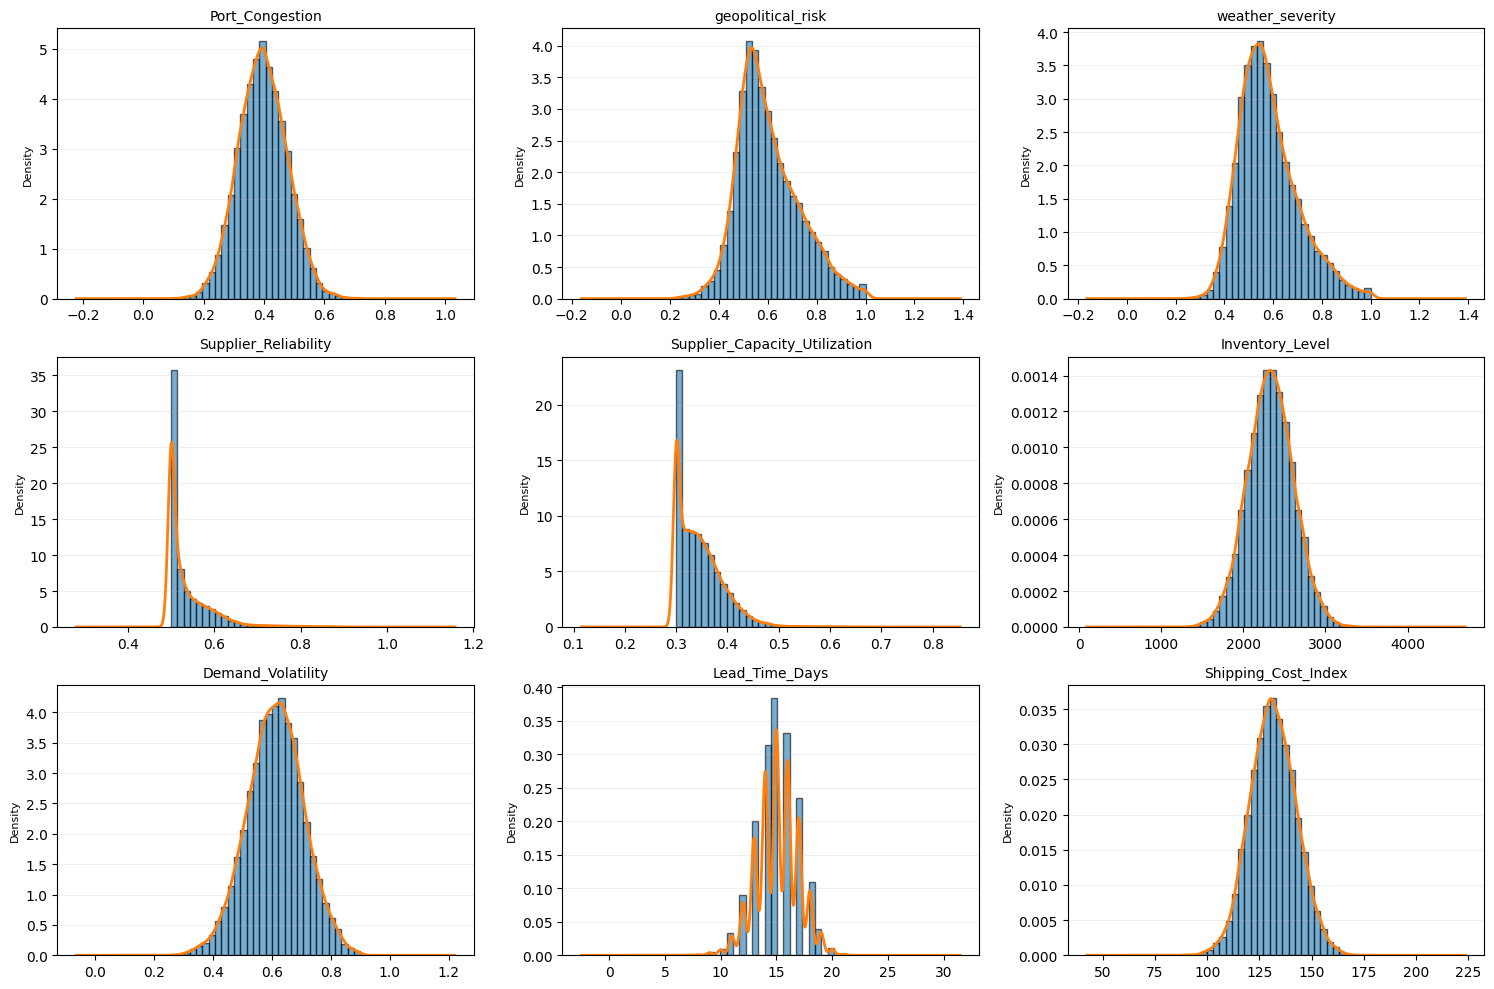

In [7]:
distribution_cols = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

# --------------------------------------------------
# 1. Descriptive Statistics
# --------------------------------------------------
display(df[distribution_cols].describe())


# --------------------------------------------------
# 2. Histograms + KDE
# --------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

axes = axes.flatten()

for ax, col in zip(axes, distribution_cols):

    # Histogram
    ax.hist(
        df[col],
        bins=30,
        density=True,
        alpha=0.6,
        edgecolor="black"
    )

    # KDE
    df[col].plot(
        kind="kde",
        ax=ax,
        linewidth=2
    )

    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Density", fontsize=8)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [8]:

distribution_stats = df[distribution_cols].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
]).T

distribution_stats.columns = [
    "Mean",
    "Median",
    "Std",
    "Min",
    "Max"
]

print("========== Distributional Statistics ==========\n")
print(distribution_stats.round(3))

========== Distributional Statistics ==========

                                   Mean    Median      Std       Min       Max
Port_Congestion                   0.396     0.395    0.080     0.091     0.719
geopolitical_risk                 0.603     0.580    0.127     0.226     1.000
weather_severity                  0.581     0.562    0.120     0.223     1.000
Supplier_Reliability              0.535     0.512    0.053     0.500     0.938
Supplier_Capacity_Utilization     0.346     0.337    0.044     0.300     0.669
Inventory_Level                2329.507  2329.000  281.014  1244.000  3551.000
Demand_Volatility                 0.613     0.614    0.096     0.258     0.900
Lead_Time_Days                   15.083    15.000    1.871     6.000    23.000
Shipping_Cost_Index             131.617   131.364   11.042    87.594   178.259


## Target Variable Distribution

In [9]:
print(df["Risk_Level"].value_counts())

Risk_Level
Low       8000
Medium    7000
High      5000
Name: count, dtype: int64


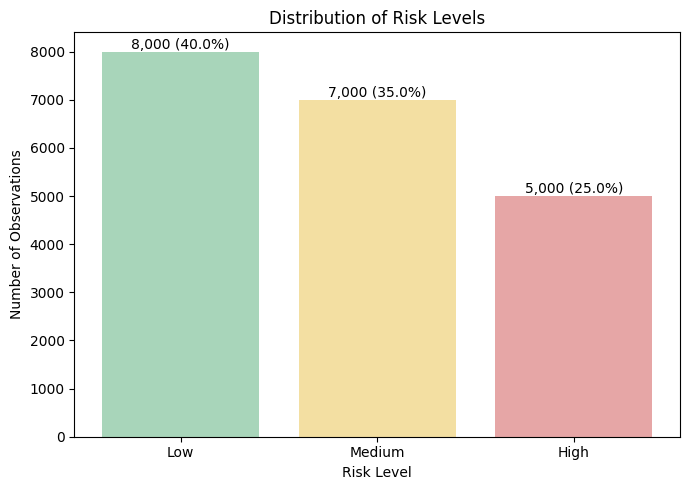

In [10]:
import matplotlib.pyplot as plt

order = ["Low", "Medium", "High"]
risk_counts = df["Risk_Level"].value_counts().reindex(order)
total = len(df)

colors = ["#A8D5BA", "#F3DFA2", "#E6A6A6"]

plt.figure(figsize=(7, 5))
bars = plt.bar(risk_counts.index, risk_counts.values, color=colors)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")

for bar, count in zip(bars, risk_counts.values):
    percentage = (count / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,} ({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Correlation Heatmap

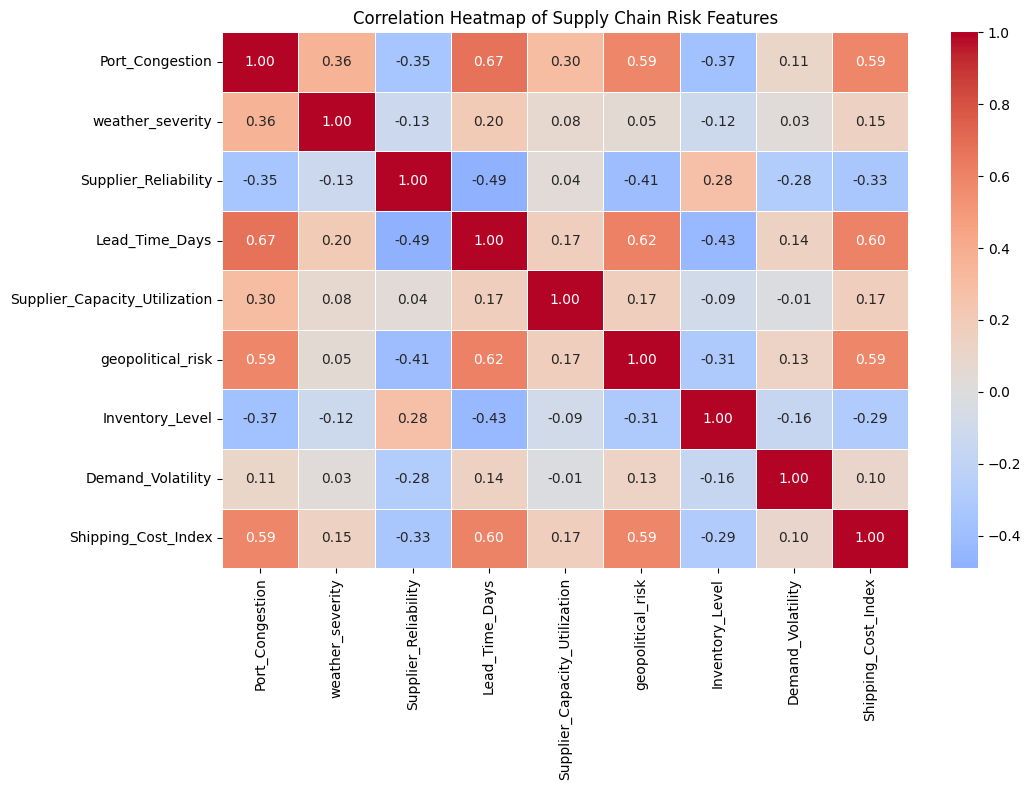

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [
    "Port_Congestion",
    "weather_severity",
    "Supplier_Reliability",
     "Lead_Time_Days",
    "Supplier_Capacity_Utilization",
    "geopolitical_risk",
    "Inventory_Level",
    "Demand_Volatility",
    "Shipping_Cost_Index"
]

corr = df[feature_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Supply Chain Risk Features")
plt.tight_layout()
plt.show()

In [12]:
corr = df[feature_cols].corr()
print(corr.round(2))

                               Port_Congestion  weather_severity  \
Port_Congestion                           1.00              0.36   
weather_severity                          0.36              1.00   
Supplier_Reliability                     -0.35             -0.13   
Lead_Time_Days                            0.67              0.20   
Supplier_Capacity_Utilization             0.30              0.08   
geopolitical_risk                         0.59              0.05   
Inventory_Level                          -0.37             -0.12   
Demand_Volatility                         0.11              0.03   
Shipping_Cost_Index                       0.59              0.15   

                               Supplier_Reliability  Lead_Time_Days  \
Port_Congestion                               -0.35            0.67   
weather_severity                              -0.13            0.20   
Supplier_Reliability                           1.00           -0.49   
Lead_Time_Days                     

## Autocorrelation checks

In [13]:
# Sort data by supplier and time
df_sorted = df.sort_values(["Supplier_ID", "Timestamp"]).copy()

# Calculate autocorrelation for each supplier
lags = [1, 2, 3, 7, 14]

results = []

for lag in lags:
    supplier_acf = (
        df_sorted
        .groupby("Supplier_ID")["Risk_Score"]
        .apply(lambda x: x.autocorr(lag=lag))
    )

    results.append({
        "Lag (Days)": lag,
        "Mean Autocorrelation": supplier_acf.mean()
    })

acf_table = pd.DataFrame(results)

display(acf_table.round(3))

,Lag (Days),Mean Autocorrelation
0,1,0.805
1,2,0.758
2,3,0.715
3,7,0.552
4,14,0.343


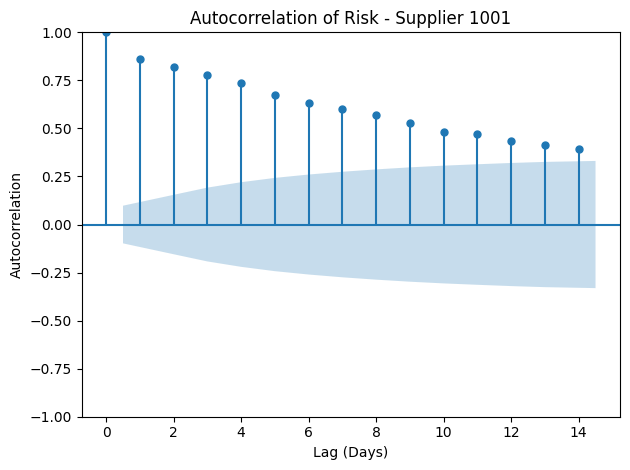

In [14]:
supplier = df[df["Supplier_ID"] == 1001].sort_values("Timestamp")

plot_acf(supplier["Risk_Score"], lags=14)

plt.title("Autocorrelation of Risk - Supplier 1001")
plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [15]:
df = df.sort_values(["Supplier_ID", "Timestamp"])

# Calculate autocorrelation for Port_Congestion, Lead_Time_Days, Demand_Volatility and Shipping_Cost_Index
variables = [
    "Port_Congestion",
    "Lead_Time_Days",
    "Demand_Volatility",
    "Shipping_Cost_Index"
]

for col in variables:
    print(f"\n{col}")

    for lag in [1, 2, 3, 7]:
        values = (
            df.groupby("Supplier_ID")[col]
            .apply(lambda x: x.autocorr(lag=lag))
            .dropna()
        )

        print(f"Lag {lag}: {values.mean():.3f}")


Port_Congestion
Lag 1: 0.835
Lag 2: 0.712
Lag 3: 0.614
Lag 7: 0.380

Lead_Time_Days
Lag 1: 0.500
Lag 2: 0.462
Lag 3: 0.429
Lag 7: 0.318

Demand_Volatility
Lag 1: 0.911
Lag 2: 0.829
Lag 3: 0.755
Lag 7: 0.515

Shipping_Cost_Index
Lag 1: 0.383
Lag 2: 0.354
Lag 3: 0.327
Lag 7: 0.248
